#### 선형회귀와 경사하강법의 학습방법
- 경사하강법 : 모델의 최적화된 방법을 찾도록 도움을 주는 것 
- 가중치와 절편을 이용해 최적화된 모델을 찾아준것 => 경사하강법 + 선형회귀 
- SGD(Stochasic Gradient Descent)가 가중치와 절편을 이용해 오차(절대값, 제곱)를 줄여 정답에 가까워지게 함
- 경사하강법을 사용하지 않는다면 모든 경우의 수를 다 찾아야 한다. 
#### 선형회귀식의 가중치(w)와 절편(bias) => Y=wX + b
머신러닝/딥러닝의 학습이란? 데이터를 계속 업데이트 하면서 모델에 적용시키면서 오차가 가장 적은 것을 기준으로 가중치와 절편을 찾는것     
규칙이란? 가중치와 절편을 계속 업데이트 하는 것     
규제란? 과대적합(train은 잘맞추나 test는 잘 못맞춤)을 방지하기 위해 가중치와 절편을 줄임 

### 당뇨병 환자 데이터

In [1]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes() # bunch class

In [2]:
# 데이터의 크기 확인하기
print(diabetes.data.shape)
print(diabetes.target.shape)

(442, 10)
(442,)


In [3]:
diabetes.feature_names

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

In [4]:
diabetes.data[:3]

array([[ 0.03807591,  0.05068012,  0.06169621,  0.02187239, -0.0442235 ,
        -0.03482076, -0.04340085, -0.00259226,  0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, -0.02632753, -0.00844872,
        -0.01916334,  0.07441156, -0.03949338, -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, -0.00567042, -0.04559945,
        -0.03419447, -0.03235593, -0.00259226,  0.00286131, -0.02593034]])

In [5]:
diabetes.target[:3]

array([151.,  75., 141.])

In [6]:
# 당뇨병 환자 데이터 시각화 하기 (bmi)
import matplotlib.pyplot as plt

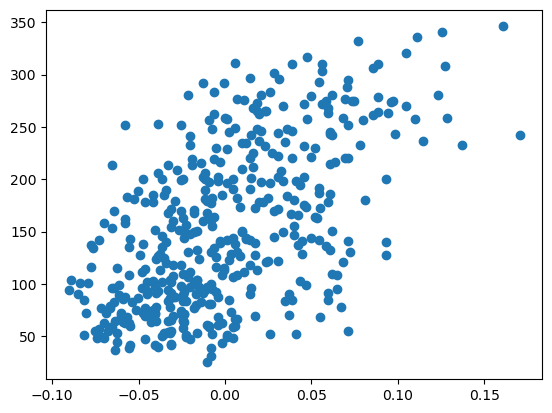

In [7]:
plt.scatter(
    diabetes.data[:,2],
    diabetes.target
)
plt.show()

In [8]:
# 상관계수
import numpy as np
np.corrcoef(diabetes.data[:,2], diabetes.target)

array([[1.        , 0.58645013],
       [0.58645013, 1.        ]])

----
#### 경사하강법
: 경사하강법은 모델이 데이터를 잘 표현할 수 있도록 기울기(변화율)을 사용하여 모델을 조금씩 조정하는 최적화 알고리즘
#### 예측값과 변화율
변화율 = 0: 최적화된 모델(Y-Y^ = 0) : 기울기 => 0
#### 예측값(Y^)
예측값은 하나의 모델에서 수식의 결과로 나온 값을 의미     
예측값이 정답값으로 수렴해야 한다. 
#### 훈련데이터에서 잘 맞는 w와 b를 찾는 방법
1. 무작위로 w와 b를 정한다.    
2. x에서 샘플 하나를 선택하여 Y^을 계산한다.     
3. Y^과 선택한 샘플의 Y를 비교한다.(예측값과 정답 비교하기 : 오차 구하기)     
4. Y^과 Y가 가까워지도록 w,b를 조정한다. (모델 조정하기 : 학습하기)
5. 모든 샘플을 처리할때 까지 2~4항목을 반복한다.    


In [9]:
# 훈련데이터의 Feature와 Target 정하기
x = diabetes.data[:,2]
y = diabetes.target 

# 5개만 출력하기
print(x[:5])
print(y[:5])

[ 0.06169621 -0.05147406  0.04445121 -0.01159501 -0.03638469]
[151.  75. 141. 206. 135.]


---

In [10]:
# w와 b를 초기화 하기 : 무작위로
w = 1
b = 1

In [11]:
# 훈련데이터의 첫번째 샘플로 Y^ 계산하기
y_hat = x[0] * w + b 
y_hat

1.0616962065186832

In [12]:
# Taget 과 예측 데이터 비교하기
print(y_hat)
print(y[0])

1.0616962065186832
151.0


> 당연한 결과지만 Target과 예측값이 너무 많은 차이가 발생

In [13]:
# w와 b를 조금 변경해서 y_hat이 증가하는지 감소하는지 살펴보기
# 기본 w에 0.1만 증가해 보기
w_inc = w + 0.1
y_hat_inc = w_inc * x[0] + b
y_hat_inc

1.0678658271705517

> y_hat보다 y_hat_inc가 조금더 Target에 근접해짐

In [14]:
# w값 조정후 예측값 정보 확인하기
# w가 0.1증가했을때 y_hat이 얼마나 증가했는지 계산해보기(변화율 확인하기)
w_rate = (y_hat_inc - y_hat) / (w_inc - w)
w_rate

0.06169620651868429

In [15]:
# 0.1 -> 0.2
w_inc = w + 0.2
y_hat_inc = w_inc * x[0] + b
w_rate = (y_hat_inc - y_hat) / (w_inc - w)
w_rate

0.06169620651868325

> w_rate(변화율)이 x[0]의 값과 동일하다.

In [16]:
# 변화율이 확인되었으나 다시 훈련데이터의 1번값으로 변화율을 구해보자
w=b=1
y_hat = x[0]*w + b
w_inc = w + 0.1
y_hat_inc = w_inc * x[0] + b
w_rate = (y_hat_inc - y_hat) / (w_inc - w)
w_rate

0.06169620651868429

In [17]:
# 변화율로 가중치 업데이트 : 학습하기
w_new = w + w_rate
w_new

1.0616962065186843

In [18]:
# 변화율로 절편 업데이트 : 학습하기
b_inc = b + 0.1
y_hat_inc = w * x[0] + b_inc
print(y_hat_inc)

1.1616962065186833


In [19]:
b_rate = (y_hat_inc - y_hat) / (b_inc - b)
b_rate

1.0

In [20]:
b_new = b + 1
b_new

2

#### 오차 역전파(backpropagation)

In [21]:
# 오차역전파로 가중치와 절편을 업데이트 하자 : 손실함수(비용함수)를 구성하자 
# 오차 역전파는 y^과 y의 차이를 이용하여 w와 b를 업데이터 합니다.
# 오차와 변화율을 곱하여 가중치 업데이트 합니다.
err = y[0] - y_hat
w_new = w + w_rate * err
b_new = b + b_rate * err
print(w_new, b_new)

10.250624555903848 150.9383037934813


In [22]:
# 2번째 샘플을 사용하여 오차를 구하고 새로운 w와 b를 구하기
y_hat = w_new * x[1] + b_new
err = y[1] - y_hat
w_rate = x[1]
w_new = w_new + w_rate * err 
b_new = b_new + 1 * err
print(w_new, b_new)

14.132317616380695 75.52764127612656


#### 반복문을 통한 전체 샘플 계산하기

In [24]:
w=b=1
for x_i, y_i in zip(x, y):
    # print(x_i, y_i)
    y_hat = x_i * w + b
    err = y_i - y_hat 
    w_rate = x_i
    w = w + w_rate * err 
    b = b + 1 * err 
print(w, b)

587.8654539985616 99.4093556453094


### 그래프로 확인

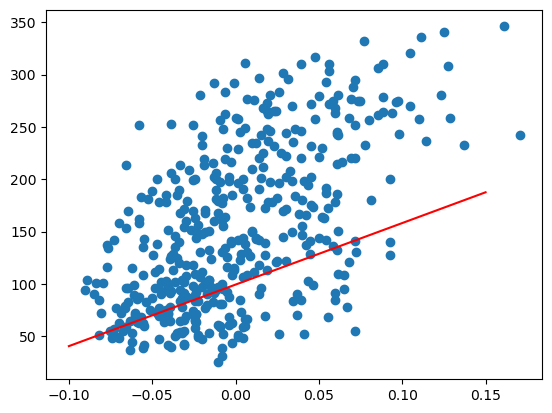

In [27]:
plt.scatter(x, y)
pt1 = (-0.1, -0.1 * w + b)
pt2 = (0.15, 0.15 * w + b)
plt.plot([pt1[0], pt2[0]], [pt1[1], pt2[1]], c='red')
plt.show()

### Epoch로 반복하기 : Data를 반복적으로 사용하기

In [37]:
w=b=1
for _ in range(100):
    for x_i, y_i in zip(x, y):
        # print(x_i, y_i)
        y_hat = x_i * w + b
        err = y_i - y_hat 
        w_rate = x_i
        w = w + w_rate * err 
        b = b + 1 * err 
print(w, b)

913.5973364346786 123.39414383177173


y^ = 913.6 * X + 123.4 

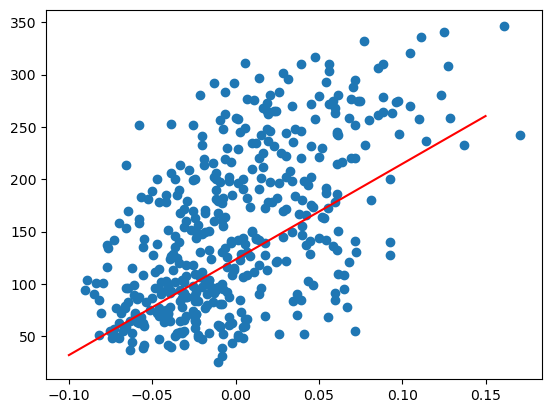

In [38]:
plt.scatter(x, y)
pt1 = (-0.1, -0.1 * w + b)
pt2 = (0.15, 0.15 * w + b)
plt.plot([pt1[0], pt2[0]], [pt1[1], pt2[1]], c='red')
plt.show()

### 선형회귀를 위한 Class 만들기

In [39]:
class LRModel:
    # 초기화 작업
    def __init__(self):
        self.w = 1.0 # 가중치의 초기화
        self.b = 1.0 # 절편의 초기화 

    # 정방향 계산 
    def forpass(self, x):
        y_hat = x * self.w + self.b # 직선방정식 계산
        return y_hat

    # 역방향 계산(오차율이 들어감)
    def backprop(self, x, err):
        w_grad = x * err # 가중치에 대한 그레디언트를 계산
        b_grad = 1 * err # 절편에 대한 그레디언트를 계산
        return w_grad, b_grad
    
    def fit(self, x, y, epoch):
        for _ in range(epoch):
            for x_i, y_i in zip(x,y):
                y_hat = self.forpass(x_i)
                err = y_i - y_hat 
                w_grad, b_grad = self.backprop(x_i, err)
                self.w += w_grad
                self.b += b_grad
        return self.w, self.b 

In [42]:
lrmodel = LRModel()
w, b = lrmodel.fit(x, y, 100)
print(w, b)

913.5973364346786 123.39414383177173


---
### 선형회귀
선형방정식을 사용하여 연속적인 값을 예측하는 알고리즘으로 데이터를 가장 잘 표현하는 방정식의 계수를 구할 수 있습니다.      
머신러닝 알고리즘이지만 딥러닝에서 사용하는 인공신경망의 알고리즘의 기초가 됩니다.      

선형회귀 -> Logistic Regression -> 인공신경망 -> Deep Learning     